# SciFact EDA

SciFact is the first dataset used to test the retrieval pipeline.

BEIR dataset facts:
- 5,183 scientific abstracts
- 300 labeled test queries
- ~1.1 relevant documents per query
- binary relevance labels

In [1]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import pandas as pd
import matplotlib.pyplot as plt

# load scifact
corpus = load_dataset(
    "BeIR/scifact",
    "corpus",
    split="corpus"
).to_pandas()

queries = load_dataset(
    "BeIR/scifact",
    "queries",
    split="queries"
).to_pandas()

# basic text characteristics
corpus["word_count"] = (
    corpus["text"]
    .fillna("")
    .str.split()
    .str.len()
)

queries["word_count"] = (
    queries["text"]
    .fillna("")
    .str.split()
    .str.len()
)

corpus["has_title"] = (
    corpus["title"]
    .fillna("")
    .str.strip()
    .ne("")
)

# pilot embedding model
model_name = "sentence-transformers/multi-qa-MiniLM-L6-cos-v1"

model = SentenceTransformer(
    model_name,
    device="cpu"
)

tokenizer = model.tokenizer
max_length = model.max_seq_length

# same document representation used in the pilot retrieval
document_texts = (
    corpus["title"].fillna("").str.strip()
    + " "
    + corpus["text"].fillna("").str.strip()
).str.strip()

query_texts = (
    queries["text"]
    .fillna("")
    .str.strip()
)

# token lengths
corpus["token_count"] = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in document_texts
]

queries["token_count"] = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in query_texts
]

documents_over_limit = corpus["token_count"] > max_length
queries_over_limit = queries["token_count"] > max_length

# summary
print("QUERY WORD LENGTH")
print(queries["word_count"].describe())

print("\nDOCUMENT WORD LENGTH")
print(corpus["word_count"].describe())

print(
    "\nDOCUMENTS WITH TITLE:",
    f"{corpus['has_title'].mean():.1%}"
)

print("\nMODEL")
print("name:", model_name)
print("max sequence length:", max_length)

print("\nQUERY TOKEN LENGTH")
print(queries["token_count"].describe())
print("queries above max length:", queries_over_limit.sum())
print(
    "percentage above max length:",
    f"{queries_over_limit.mean():.2%}"
)

print("\nDOCUMENT TOKEN LENGTH")
print(corpus["token_count"].describe())
print("documents above max length:", documents_over_limit.sum())
print(
    "percentage above max length:",
    f"{documents_over_limit.mean():.2%}"
)

print("\nPILOT RETRIEVAL")
print("test queries: 300")
print("nDCG@10: 0.5403")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


QUERY WORD LENGTH
count    1109.000000
mean       12.379621
std         4.795566
min         3.000000
25%         9.000000
50%        12.000000
75%        15.000000
max        39.000000
Name: word_count, dtype: float64

DOCUMENT WORD LENGTH
count    5183.000000
mean      201.810920
std        86.007594
min        26.000000
25%       147.000000
50%       192.000000
75%       247.000000
max      1524.000000
Name: word_count, dtype: float64

DOCUMENTS WITH TITLE: 100.0%

MODEL
name: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
max sequence length: 512

QUERY TOKEN LENGTH
count    1109.000000
mean       22.441839
std         8.095632
min         7.000000
25%        17.000000
50%        21.000000
75%        26.000000
max        79.000000
Name: token_count, dtype: float64
queries above max length: 0
percentage above max length: 0.00%

DOCUMENT TOKEN LENGTH
count    5183.000000
mean      337.194482
std       138.769336
min        70.000000
25%       244.500000
50%       316.000000
75%     

## Key Findings

- queries are short: median 12 words / 21 tokens
- no queries exceed the pilot model's 512-token limit
- documents are longer: median 192 words / 316 tokens
- 455 documents (8.78%) exceed 512 tokens
- all documents have titles

The main constraint is document length, not query length. Model context length and document handling should be considered when choosing the fixed retriever

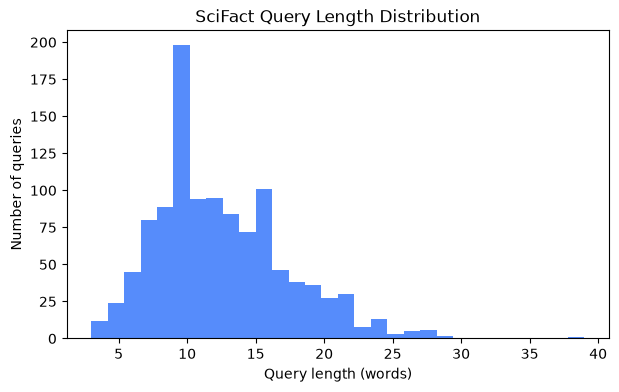

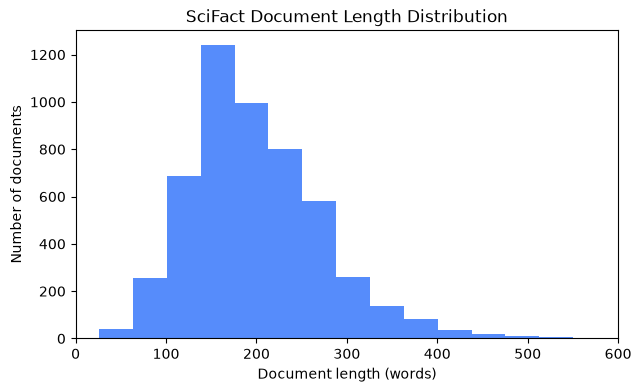

In [2]:
# plots
plt.figure(figsize=(7, 4))
plt.hist(queries["word_count"], bins=30)
plt.xlabel("Query length (words)")
plt.ylabel("Number of queries")
plt.title("SciFact Query Length Distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(corpus["word_count"], bins=40)
plt.xlabel("Document length (words)")
plt.ylabel("Number of documents")
plt.title("SciFact Document Length Distribution")
plt.xlim(0, 600)
plt.show()

## Pilot Retrieval

For a pipeline check, I used `multi-qa-MiniLM-L6-cos-v1` with exact cosine retrieval in FAISS

- test queries: 300
- nDCG@10: **0.5403**

**pilot result**. have not choose embedding model or document handling strategy yet

In [3]:
model = SentenceTransformer(
    "sentence-transformers/multi-qa-MiniLM-L6-cos-v1",
    device="cpu"
)

tokenizer = model.tokenizer
max_length = model.max_seq_length

document_texts = (
    corpus["title"].fillna("").str.strip()
    + " "
    + corpus["text"].fillna("").str.strip()
).str.strip()

token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in document_texts
]

corpus["token_count"] = token_lengths

truncated = corpus["token_count"] > max_length

print("model max sequence length:", max_length)
print("documents above max length:", truncated.sum())
print("percentage above max length:", f"{truncated.mean():.2%}")
print("maximum token count:", corpus["token_count"].max())

print("\nclean baseline nDCG@10: 0.5403")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


model max sequence length: 512
documents above max length: 455
percentage above max length: 8.78%
maximum token count: 1939

clean baseline nDCG@10: 0.5403
